In [13]:
import warnings
warnings.filterwarnings('ignore')

import yaml
import os
import sys
# add the project root to the path so the src package can be imported
sys.path.append(os.path.abspath('..'))
from src.inference_pipeline import run_pipeline,load_recommended_models
from src.vis import (
    visualize_quadrant_stage, visualize_teeth_stage,
    visualize_healthy_unhealthy_stage, visualize_disease_stage, visualize_final_result
)
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np

with open('../configs/trained_models.yaml', 'r') as f:
    all_trained_models = yaml.safe_load(f)
    final_models = all_trained_models['final_recommended_models']

In [ ]:
models = load_recommended_models(
    final_models,
    device='cuda'
)

clear_output(wait=True)

class_names = {
    'teeth': [str(i) for i in range(8)],
    'healthy_unhealthy': ['Disease Found', 'Healthy'],
    'disease': ['Impacted', 'Caries', 'Periapical'],
    'caries_severity': ['Caries', 'Deep Caries'],
}

testset_path = r'..\Data\Raw\DENTEX CHALLENGE 2023\Test_Data\quadrant_enumeration_disease\xrays'
random_testset_image = np.random.choice(os.listdir(testset_path))
random_image_path = os.path.join(testset_path,random_testset_image)

result, warnings = run_pipeline(
    image_path=random_image_path,
    models=models,
    class_names=class_names,
    device='cuda'
)


# print('Warnings:', warnings)
print('Diseased teeth found:', len(result['diseased_teeth']))
for t in result['diseased_teeth']:
    probs = {
        cls: f"{prob * 100:.2f}"
        for cls, prob in t.get('disease_probs', {}).items()
    }

    print(
        t['quad_key'],
        t.get('class_name'),
        t.get('disease'),
        probs,
        t.get('caries_severity'),
        t.get('caries_severity_probs')
          )

100%|██████████| 4/4 [00:00<00:00, 11.80it/s]


Warnings: ['missing_teeth: tooth 5 & 7 (confidence: nan)', 'needs_manual_review: tooth tooth 6 box is 2.7x the median width, may span two teeth (confidence: nan)', 'missing_teeth: tooth 7 (confidence: nan)', 'needs_manual_review: tooth tooth 5 box is 1.9x the median width, may span two teeth | tooth 6 box is 2.1x the median width, may span two teeth (confidence: nan)', 'low_confidence: tooth 6 (confidence: 0.5)', 'missing_teeth: tooth 5 & 7 (confidence: nan)', 'missing_teeth: tooth 5 & 7 (confidence: nan)']
Diseased teeth found: 3
val_48_LowerRight 5 Caries {'Impacted': '1.02%', 'Caries': '77.36%', 'Periapical': '21.62%'} Caries {'Caries': 72.14, 'Deep Caries': 27.86}
val_48_UpperLeft 6 Caries {'Impacted': '6.40%', 'Caries': '85.30%', 'Periapical': '8.30%'} Caries {'Caries': 75.59, 'Deep Caries': 24.41}
val_48_UpperRight 6 Caries {'Impacted': '1.25%', 'Caries': '49.71%', 'Periapical': '49.05%'} Caries {'Caries': 72.51, 'Deep Caries': 27.49}


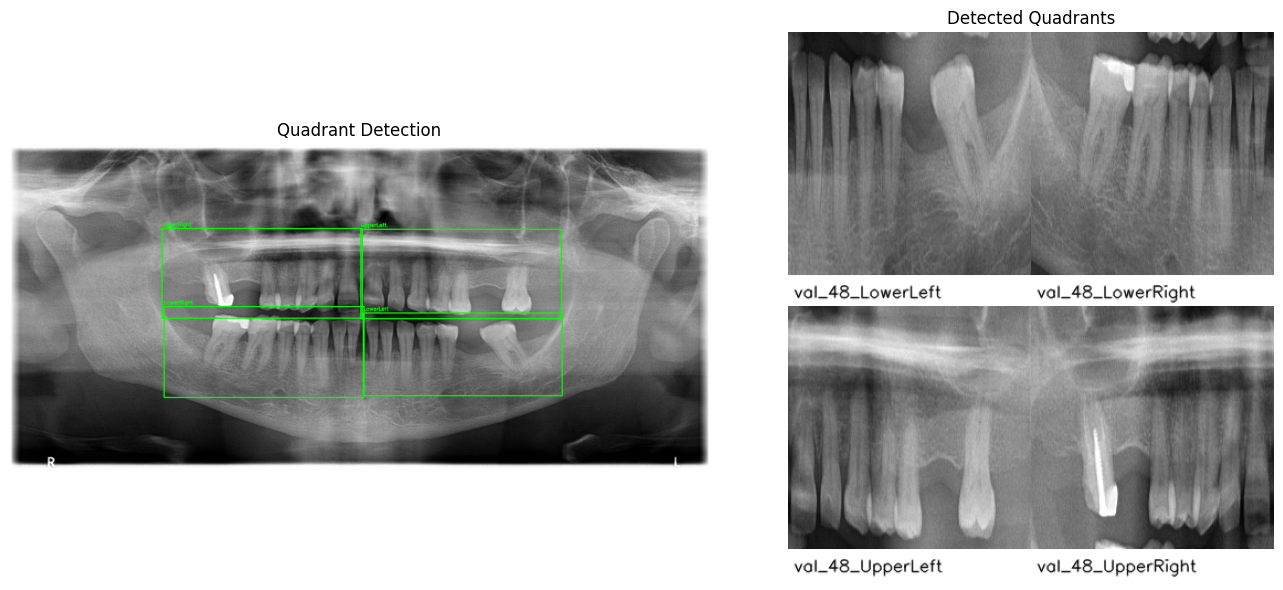

In [15]:
visualize_quadrant_stage(result)
plt.show()

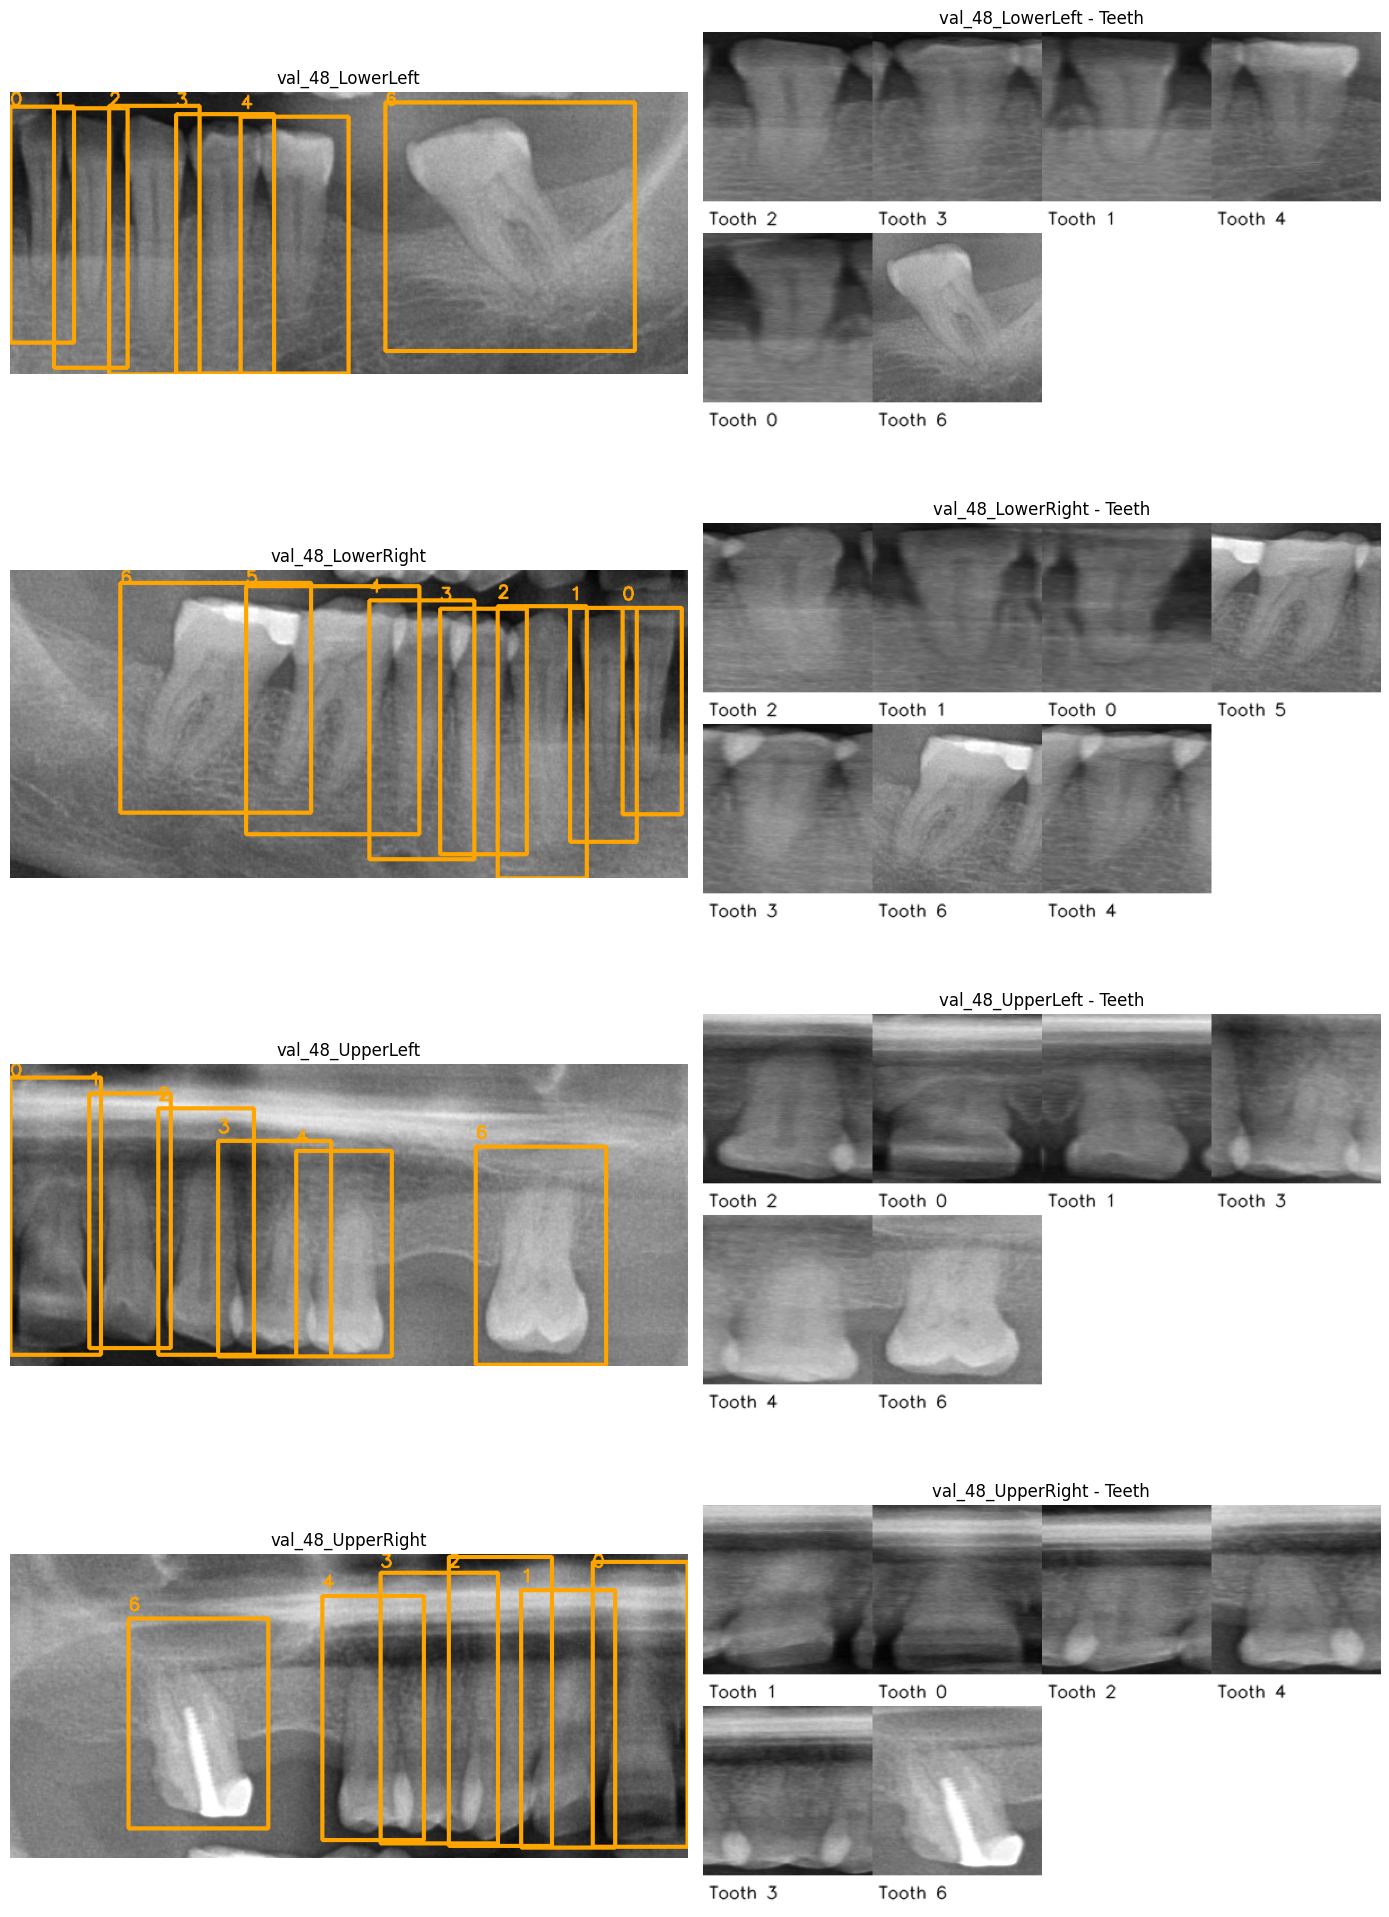

In [16]:
visualize_teeth_stage(result)
plt.show()

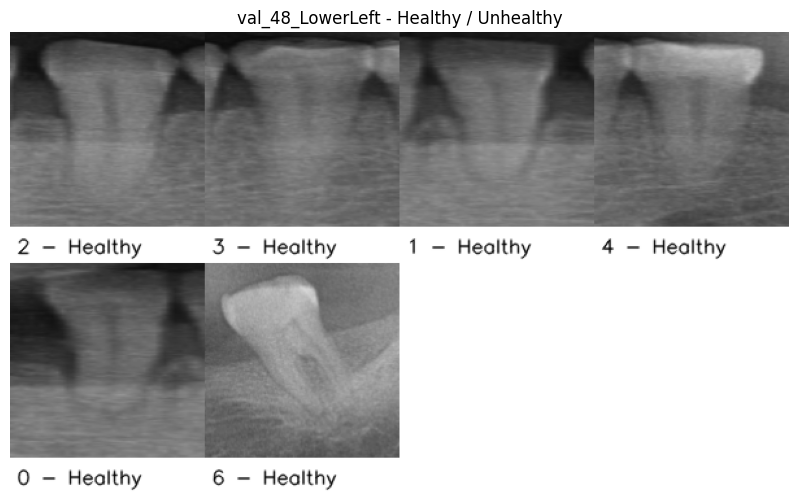

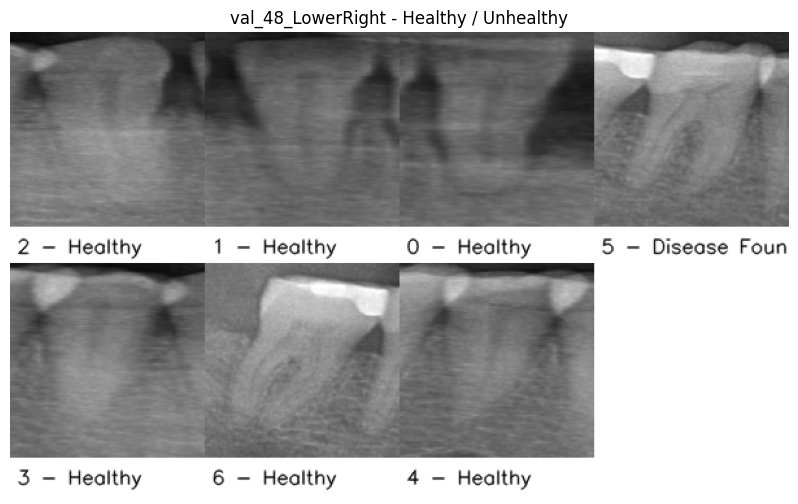

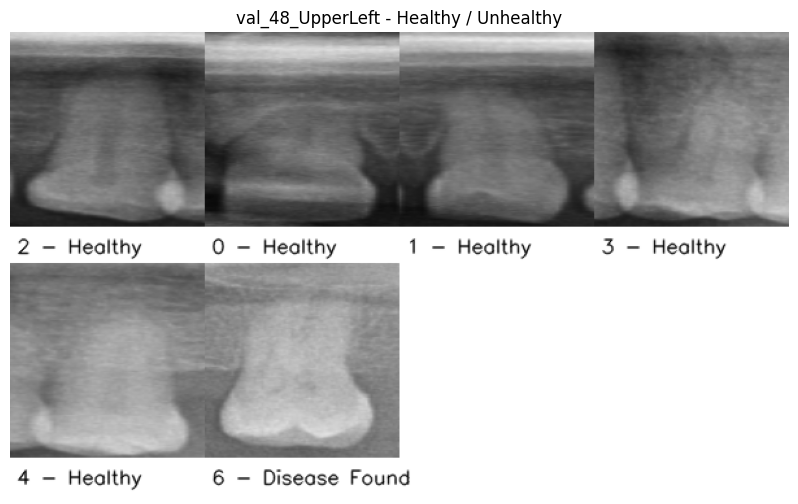

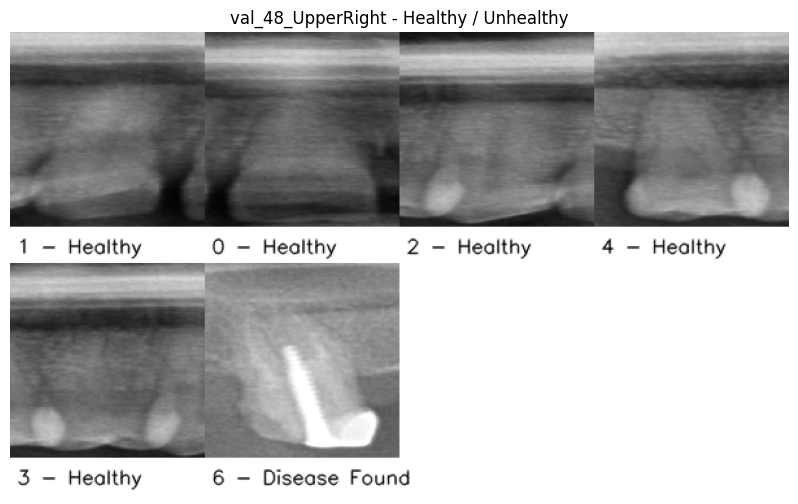

In [17]:
for fig in visualize_healthy_unhealthy_stage(result):
    plt.show()

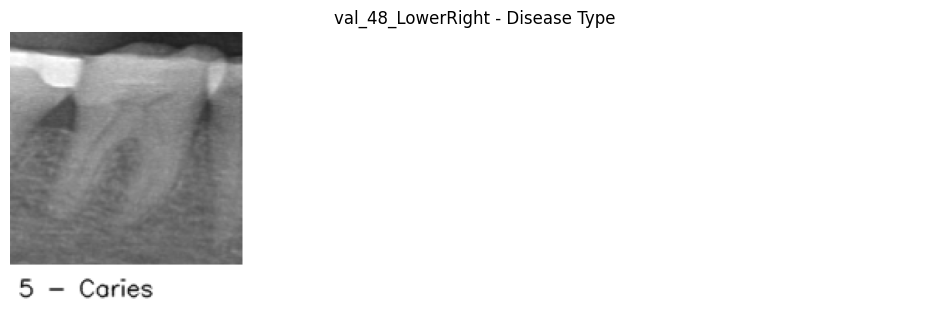

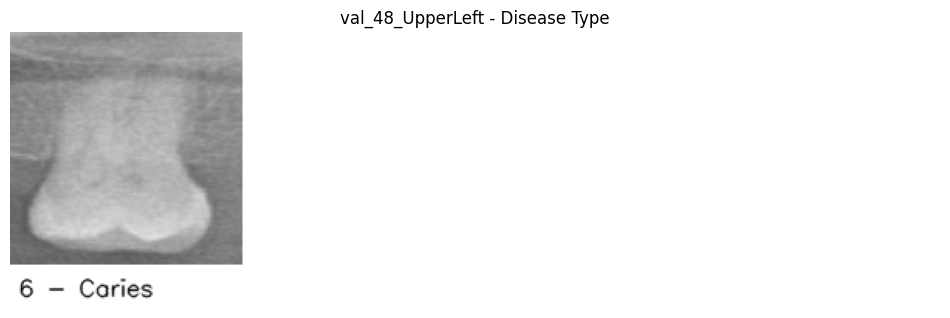

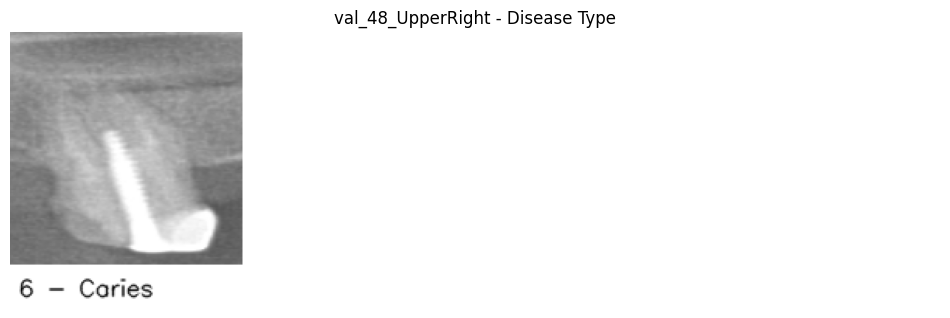

In [18]:
for fig in visualize_disease_stage(result):
    plt.show()

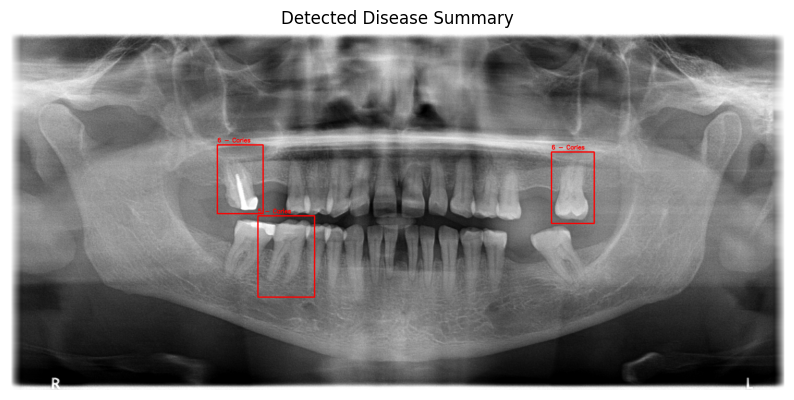

In [19]:
visualize_final_result(result)
plt.show()